# Étape 2

Étape 2 : Étape de nettoyage Dans cette étape, on s’intéresse à implémenter les correctifs soulignés dans l’étape 1. De ce fait, il serait important de considérer les opérations suivantes : 

* Imputing: évaluer les colonnes avec des valeurs manquantes. Par exemple, voir les colonnes: 
* title, revol_util et pub_rec_bankruptcies Une stratégie à employer: Supprimer la colonne ayant plus de 1 à 2% de valeurs manquantes Supprimer les lignes ayant des valeurs NaN  

* Convertir les colonnes catégorielles en numériques. Faire attention ici aux valeurs ordinales et nominales (dummy var).  

* Suppression de colonnes non adéquates pour la prédiction  

* Suppression des colonnes qui ne seront intéressantes que pour prédire le statut de paiement du prêt. Les colonnes dont les valeurs seront obtenues après le prêt ne doivent pas être considérées. Par exemple, évaluer si les colonnes suivantes sont à supprimer:  

	* zip_code  
	* out_prncp  
	* out_prncp_inv  
	* total_pymnt  
	* total_pymnt_inv  
	* total_rec_prncp  
	* total_rec_int  
	* total_rec_late_fee  
	* recoveries  
	* collection_recovery_fee  
	* last_pymnt_d  
	* last_pymnt_amnt  

Vérifier si la colonne cible est dans un format adéquat pour le modèle.  

Correction/Standardisation/Normalisation de données  

In [89]:

import pandas as pd 
import numpy as np
from utils.utils import distributional_summary, degree_completeness, plot_distributions, plot_boxplots
import matplotlib.pyplot as plt 
from typing import Dict, List, Callable, Any, Tuple
from sklearn.preprocessing import StandardScaler


df_data = pd.read_csv('data/lending_club_loans.csv') 
labels = pd.read_excel('data/lending_club_data_dic.xlsx') 
labels.index = labels['LoanStatNew']
labels = labels.drop(columns=['LoanStatNew'])
labels = labels.loc[df_data.columns] # ! limits labels to our variables of interests


def convert_percentage(serie:pd.Series):
	'''
	returns float serie from a percentage string serie 
	'''
	return [ float(str(v).replace('%', '')) for v in serie.values]



def convert_date(serie:pd.Series): 
	'''
	returns datetime serie from a string serie
	'''
	return pd.to_datetime(serie, format='%b-%y') 



def delta_month(d1:pd.Series, d2:pd.Series):
	return ( (d1.dt.year - d2.dt.year) * 12 + (d1.dt.month - d2.dt.month) ).astype('Int64')



def mean_category(serie:pd.Series, encoding:dict) -> str:
	'''
	returns the mean category for ordinal categorical values. 
	'''
	reversed = { v:k for k,v in encoding.items() } # ! reverse to encoding to get conversion FROM cat -> num instead of num -> cat 
	mean = round(pd.Series([ reversed.get(v, np.nan) for v in serie.values ]).mean(), 0) 
	return encoding[mean] 



def has_outliers(serie:pd.Series):
	'''
	returns true if the serie has possible outliers, else false
	'''
	Q1 = serie.quantile(0.25) # ! Critere a 25 quartile
	Q3 = serie.quantile(0.75) # ! Critere a 75 quartile
	IQR = Q3 - Q1 
	outlier = (serie < (Q1 -1.5 * IQR)) | (serie > (Q3 + 1.5 * IQR)) 
	return any(outlier) 



# ! Identify varnames groups for particular treatments later 
summary = distributional_summary(df_data) 
varname_id = ['id', 'member_id'] 
varname_cardinality_1 = summary.loc[:, summary.loc['cardinality'] == 1].columns # ! to document. 
varname_date = ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line', 'issue_d'] 
varname_percentage = ['int_rate', 'revol_util'] 


## Encodage des variables categoriques

In [90]:

# ! Infer encoding values for categorical values 
df = df_data.copy() 
cat_var = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'addr_state'] 

encodings = {
  'emp_length':{
    0: '< 1 year',
    1: '1 year',
    2: '2 years',
    3: '3 years',
    4: '4 years',
    5: '5 years',
    6: '6 years',
    7: '7 years',
    8: '8 years',
    9: '9 years',
    10: '10+ years'}
}

for c in cat_var:
	encodings[c] = { i:v for i,v in enumerate(sorted(df[c].unique()))}

varname_cat = list(encodings.keys())

### Regle de transformations. 
* Correction: il faudra regrouper les valeurs possibles de 'loan_status' en 2 categorie; 1:'Fully Paid', 0:'Not-fully paid' 
* Corrections: Variables avec cardinality de 1, retirer ces 7 colonnes de notre dataset.
* Correction: Convertir au format "float" les variables pourcentages.
* Corrections: Convertir au format "datetime" lorsque necessaire.
* Corrections: Des outliers sont identifiables sur des distributions positives; ces variables auront des (log +1) transformations pour reduire l'importances des valeurs extremes. 
* Corrections: Certaines imputations sont possibles sur les valeurs manquantes (voir imputations_mapper plus bas). 
	(Plus de detail dans les commentaires de la cellules plus bas). 
	Apres une les transformation il y aura un recalcule la completude et des sommaires. 


variable a retirer = [
  # ! utiliser addr_state plutot que zip_code pour des analyses geolocalise
  'zip_code', 'last_credit_pull_d', 
  # ! C'est valeurs semblent etre obtenues apres le pret 
  'last_pymnt_d', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv', 
  'total_pymnt', 'total_pymnt_inv', 'total_rec_late_fee', 
  'recoveries', 'collection_recovery_fee', 'loan_status', 
] 

In [91]:

# ? Template for transformation function. Helps intellisense and structures
type TransformerFunc = Callable[[pd.DataFrame, str], pd.Series] 

transform_mapper:Dict[str, Tuple[TransformerFunc, str]] = { 
	# ! convert string percentage -> numerical percentage 
  'int_rate': (lambda df,c: convert_percentage(df[c]), None), 
  'revol_util' : (lambda df,c: convert_percentage(df[c]), None), 
  
  # ! convert string date -> datetime values 
  'last_pymnt_d':	(lambda df,c: convert_date(df[c]), None), 
  'last_credit_pull_d': (lambda df,c: convert_date(df[c]), None), 
  'earliest_cr_line': (lambda df,c: convert_date(df[c]), None), 
  'issue_d': (lambda df,c: convert_date(df[c]), None), 
} 


imputations_mapper:Dict[str, Tuple[TransformerFunc, str]] = { 
	# ! Impute mean category from ORDINAL variable "emp_length" instead of using most frequent value. 
  'emp_length': (lambda df,c: mean_category(df[c], encodings[c]), 'emp_length'), 
	
	# ! Impute mean and round to integer value
	'revol_util': (lambda df, c: int(round(df[c].mean(), 0)), 'revol_util'), 
	'pub_rec_bankruptcies': (lambda df, c: int(round(df[c].mean(), 0)), 'pub_rec_bankruptcies'), 
} 

# flag_mapper:Dict[str, Tuple[TransformerFunc, str]] = { 
# 	# ! Flag missing date values instead of imputations 
# 	'last_pymnt_d': (lambda df, c: pd.notnull(df[c]), 'last_pymnt_d_flag'), # flag null values 
# 	'last_credit_pull_d': (lambda df, c: pd.notnull(df[c]), 'last_credit_pull_d_flag'), # flag null values 
# } 

temporary_variables = ['last_pymnt_d_flag', 'last_credit_pull_d_flag'] 
varname_to_remove = [
  # ! utiliser addr_state
  'zip_code', 'last_credit_pull_d', 
  # ! C'est valeurs semblent etre obtenues apres le pret 
  'last_pymnt_d', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv', 
  'total_pymnt', 'total_pymnt_inv', 'total_rec_late_fee', 
  'recoveries', 'collection_recovery_fee', 'loan_status', 
] 

In [92]:

# ! Test all relevant numerical columns for possible outliers. 
test_for_outliers = [c for c in df_data.select_dtypes('number').columns if c not in [*varname_to_remove, *varname_id]] 
cols_with_outliers = [ c for c in test_for_outliers if has_outliers(df_data[c]) ]
print(cols_with_outliers)

# ! build outliers_mappers to apply a log transformation, log transformation to reduce importance of outliers, without losing observations. 
log_trf = lambda df, c: np.log(df[c] +1)
outliers_mapper:Dict[str, Tuple[TransformerFunc, str] ] = { c: (log_trf, c) for c in cols_with_outliers } 
outliers_mapper

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment', 'annual_inc', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'total_rec_prncp', 'total_rec_int', 'pub_rec_bankruptcies']


{'loan_amnt': (<function __main__.<lambda>(df, c)>, 'loan_amnt'),
 'funded_amnt': (<function __main__.<lambda>(df, c)>, 'funded_amnt'),
 'funded_amnt_inv': (<function __main__.<lambda>(df, c)>, 'funded_amnt_inv'),
 'installment': (<function __main__.<lambda>(df, c)>, 'installment'),
 'annual_inc': (<function __main__.<lambda>(df, c)>, 'annual_inc'),
 'delinq_2yrs': (<function __main__.<lambda>(df, c)>, 'delinq_2yrs'),
 'inq_last_6mths': (<function __main__.<lambda>(df, c)>, 'inq_last_6mths'),
 'open_acc': (<function __main__.<lambda>(df, c)>, 'open_acc'),
 'pub_rec': (<function __main__.<lambda>(df, c)>, 'pub_rec'),
 'revol_bal': (<function __main__.<lambda>(df, c)>, 'revol_bal'),
 'total_acc': (<function __main__.<lambda>(df, c)>, 'total_acc'),
 'total_rec_prncp': (<function __main__.<lambda>(df, c)>, 'total_rec_prncp'),
 'total_rec_int': (<function __main__.<lambda>(df, c)>, 'total_rec_int'),
 'pub_rec_bankruptcies': (<function __main__.<lambda>(df, c)>,
  'pub_rec_bankruptcies')}

### Execution des transformations

In [93]:

df_transformed = df_data.copy()


# ! Transformations de notre variables cible. 
# ! If loan_status == 'Fully Paid' then y = 1 else y = 0 
df_transformed['y'] = [ 1 if v == 'Fully Paid' else 0 for v in df_transformed['loan_status'].values ] 


# ! Transformations 
for varname, (func, outvarname) in transform_mapper.items(): 
	outvarname = outvarname or varname 
	df_transformed[outvarname] = func(df_transformed, varname) 

# ! Outliers 
for varname, (func, outvarname) in outliers_mapper.items(): 
	outvarname = outvarname or varname 
	df_transformed[outvarname] = func(df_transformed, varname) 

# ! Imputations 
for varname, (func, outvarname) in imputations_mapper.items(): 
	outvarname = outvarname or varname 
	df_transformed[outvarname] = df_transformed[varname].fillna(func(df_transformed, varname)) 

# # ? Not necessary if we drop date columns 
# # ! Flagging
# for varname, (func, outvarname) in flag_mapper.items(): 
# 	outvarname = outvarname or varname 
# 	df_transformed[outvarname] = func(df_transformed, varname) 


# # ! Drop flagged observations 
# varname_flag = ['last_pymnt_d_flag', 'last_credit_pull_d_flag'] #  
# to_keep = df_transformed[varname_flag].all(axis=1) 
# df_transformed['to_keep'] = to_keep
# df_rejected = df_transformed[~to_keep]  # ? Keep rejected observations for documentation purposes 
# df_transformed = df_transformed[to_keep] 

# ! Remove temporary variables 
df_transformed = df_transformed.drop(columns=[*varname_id, *varname_cardinality_1, *varname_to_remove]) 

# ! Ordonnancement des colonnes 
ordered = ['y', *[ c for c in df_transformed.columns if c != 'y']] 
df_transformed = df_transformed[ordered] 
df_transformed 


,y,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_rec_prncp,total_rec_int,pub_rec_bankruptcies
0,1,8.517393,8.517393,8.512382,36 months,10.65,5.099073,B,B2,10+ years,...,1985-01-01,0.693147,1.386294,0.0,9.521422,83.7,2.302585,8.517393,6.761758,0.0
1,0,7.824446,7.824446,7.824446,60 months,15.27,4.108083,C,C4,< 1 year,...,1999-04-01,1.791759,1.386294,0.0,7.431300,9.4,1.609438,6.125689,6.078032,0.0
2,1,7.783641,7.783641,7.783641,36 months,15.96,4.446526,C,C5,10+ years,...,2001-11-01,1.098612,1.098612,0.0,7.991931,98.5,2.397895,7.783641,6.407985,0.0
3,1,9.210440,9.210440,9.210440,36 months,13.49,5.829857,C,C1,10+ years,...,1996-02-01,0.693147,2.397895,0.0,8.630343,21.0,3.637586,9.210440,7.703423,0.0
4,1,8.006701,8.006701,8.006701,60 months,12.69,4.231058,B,B5,1 year,...,1996-01-01,0.000000,2.772589,0.0,10.232216,53.9,3.663562,8.006701,6.973459,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,1,7.824446,7.824446,6.981006,36 months,8.07,4.374750,A,A4,4 years,...,1990-11-01,0.000000,2.639057,0.0,8.892199,13.1,3.713572,7.824446,5.780651,0.0
39782,1,9.047939,9.047939,6.775366,36 months,10.28,5.621777,C,C1,3 years,...,1986-12-01,0.693147,1.945910,0.0,9.087947,26.9,2.302585,9.047939,7.254524,0.0
39783,1,8.517393,8.517393,7.189922,36 months,8.07,5.061582,A,A4,< 1 year,...,1998-10-01,0.000000,2.484907,0.0,9.179778,19.4,3.044522,8.517393,5.610058,0.0
39784,1,8.517393,8.517393,6.478510,36 months,7.43,5.052289,A,A2,< 1 year,...,1988-11-01,0.000000,2.890372,0.0,11.357534,0.7,3.295837,8.517393,5.165928,0.0


## Standardisation 

In [94]:
scaler = StandardScaler() 
df_stand = df_transformed.copy()
numeric_cols = df_stand.drop(columns=['y']).select_dtypes(include=[np.number]).columns.tolist() 

scaler.fit(df_stand[numeric_cols])  
df_stand[numeric_cols] = scaler.transform(df_stand[numeric_cols])
  
df_stand

,y,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_rec_prncp,total_rec_int,pub_rec_bankruptcies
0,1,-0.776374,-0.762421,-0.463487,36 months,-0.369659,-0.670563,B,B2,10+ years,...,1985-01-01,0.404375,-1.983501,-0.235715,0.433358,1.230353,-1.330987,-0.357527,-0.350666,-0.210142
1,0,-1.719411,-1.718728,-1.177166,60 months,0.869805,-2.087660,C,C4,< 1 year,...,1999-04-01,2.529943,-1.983501,-0.235715,-0.669644,-1.393377,-2.635781,-2.801517,-0.940098,-0.210142
2,1,-1.774943,-1.775041,-1.219499,36 months,1.054919,-1.603693,C,C5,10+ years,...,2001-11-01,1.188859,-2.650668,-0.235715,-0.373787,1.752980,-1.151573,-1.107321,-0.655649,-0.210142
3,1,0.166799,0.194024,0.260694,36 months,0.392262,0.374444,C,C1,10+ years,...,1996-02-01,0.404375,0.362515,-0.235715,-0.036883,-0.983750,1.182047,0.350671,0.461133,-0.210142
4,1,-1.471379,-1.467205,-0.988091,60 months,0.177637,-1.911808,B,B5,1 year,...,1996-01-01,-0.936709,1.231471,-0.235715,0.808460,0.178036,1.230943,-0.879384,-0.168161,-0.210142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,1,-1.719411,-1.718728,-2.052169,36 months,-1.061827,-1.706331,A,A4,4 years,...,1990-11-01,-0.936709,0.921797,-0.235715,0.101304,-1.262720,1.325084,-1.065623,-1.196467,-0.210142
39782,1,-0.054350,-0.030237,-2.265504,36 months,-0.468923,0.076893,C,C1,3 years,...,1986-12-01,0.404375,-0.685689,-0.235715,0.204604,-0.775406,-1.330987,0.184617,0.074143,-0.210142
39783,1,-0.776374,-0.762421,-1.835435,36 months,-1.061827,-0.724175,A,A4,< 1 year,...,1998-10-01,-0.936709,0.564304,-0.235715,0.253066,-1.040251,0.065651,-0.357527,-1.343533,-0.210142
39784,1,-0.776374,-0.762421,-2.573470,36 months,-1.233527,-0.737463,A,A2,< 1 year,...,1988-11-01,-0.936709,1.504623,-0.235715,1.402315,-1.700597,0.538731,-0.357527,-1.726412,-0.210142


## Dummies
Corrections generales: Toutes les categoriques doivent etre transformer en dummy en preparation a l'analyse. 

In [95]:
print(f"Variables catégorielles à encoder: {varname_cat}")
df_dummies = df_stand.copy()
df_dummies = pd.get_dummies(df_dummies, columns=varname_cat, drop_first=True, dtype=int)
print(f"\nNombre de colonnes après encoding: {df_dummies.shape[1]}")
df_dummies

Variables catégorielles à encoder: ['emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'addr_state']

Nombre de colonnes après encoding: 126


,y,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
0,1,-0.776374,-0.762421,-0.463487,-0.369659,-0.670563,-1.587999,2011-12-01,2.146113,-0.332339,...,0,0,0,0,0,0,0,0,0,0
1,0,-1.719411,-1.718728,-1.177166,0.869805,-2.087660,-1.188672,2011-12-01,-1.844474,-0.332339,...,0,0,0,0,0,0,0,0,0,0
2,1,-1.774943,-1.775041,-1.219499,1.054919,-1.603693,-2.791202,2011-12-01,-0.688476,-0.332339,...,0,0,0,0,0,0,0,0,0,0
3,1,0.166799,0.194024,0.260694,0.392262,0.374444,-0.303379,2011-12-01,1.000597,-0.332339,...,0,0,0,0,0,0,0,0,0,0
4,1,-1.471379,-1.467205,-0.988091,0.177637,-1.911808,0.566599,2011-12-01,0.692132,-0.332339,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,1,-1.719411,-1.718728,-2.052169,-1.061827,-1.706331,1.136502,2007-07-01,-0.297653,-0.332339,...,0,0,0,0,0,0,0,0,0,0
39782,1,-0.054350,-0.030237,-2.265504,-0.468923,0.076893,-2.102814,2007-07-01,-1.035874,2.262536,...,0,0,0,0,0,0,0,0,0,0
39783,1,-0.776374,-0.762421,-1.835435,-1.061827,-0.724175,0.965935,2007-07-01,-1.649811,-0.332339,...,0,0,0,0,0,0,0,0,0,0
39784,1,-0.776374,-0.762421,-2.573470,-1.233527,-0.737463,2.206394,2007-07-01,-1.437179,-0.332339,...,0,0,0,0,0,0,0,0,0,0


## Distributional summary (Apres transformation)

In [96]:
summary = distributional_summary(df_dummies) 
summary 

,y,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
type,numerical,numerical,numerical,numerical,numerical,numerical,numerical,date,numerical,numerical,...,numerical,numerical,numerical,numerical,numerical,numerical,numerical,numerical,numerical,numerical
dtype,int64,float64,float64,float64,float64,float64,float64,datetime64[ns],float64,float64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
N,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786,...,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786
count,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786,...,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786
missing_p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cardinality,2,885,1042,8215,371,15405,5323,55,2868,11,...,2,2,2,2,2,2,2,2,2,2
unique_p,0.0,0.004876,0.004424,0.179259,0.000427,0.228322,0.099708,0.000025,0.004499,0.00005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
most_freq,1,0.166799,0.194024,-0.458288,-0.278443,0.250749,0.051765,2011-12-01 00:00:00,-1.994214,-0.332339,...,0,0,0,0,0,0,0,0,0,0
least_freq,0,-0.383233,-2.82004,0.26012,1.256131,-1.259518,1.129852,2007-06-01 00:00:00,2.086217,8.28765,...,1,1,1,1,1,1,1,1,1,1
mean,0.857286,0.0,-0.0,-0.0,-0.0,-0.0,0.0,NaN,0.0,0.0,...,0.001609,0.000427,0.068718,0.00651,0.035389,0.001357,0.021163,0.011562,0.004449,0.002086


In [97]:
v_completeness = degree_completeness(df_transformed) 
h_completeness = degree_completeness(df_transformed, axis=1) 

print(f"Completude 100%? {all(v_completeness['completeness']==1)}")
v_completeness.sort_values(by='completeness') 



Completude 100%? True


,completeness
y,1.0
loan_amnt,1.0
funded_amnt,1.0
funded_amnt_inv,1.0
term,1.0
int_rate,1.0
installment,1.0
grade,1.0
sub_grade,1.0
emp_length,1.0


## Graph distribution (Apres transformation)

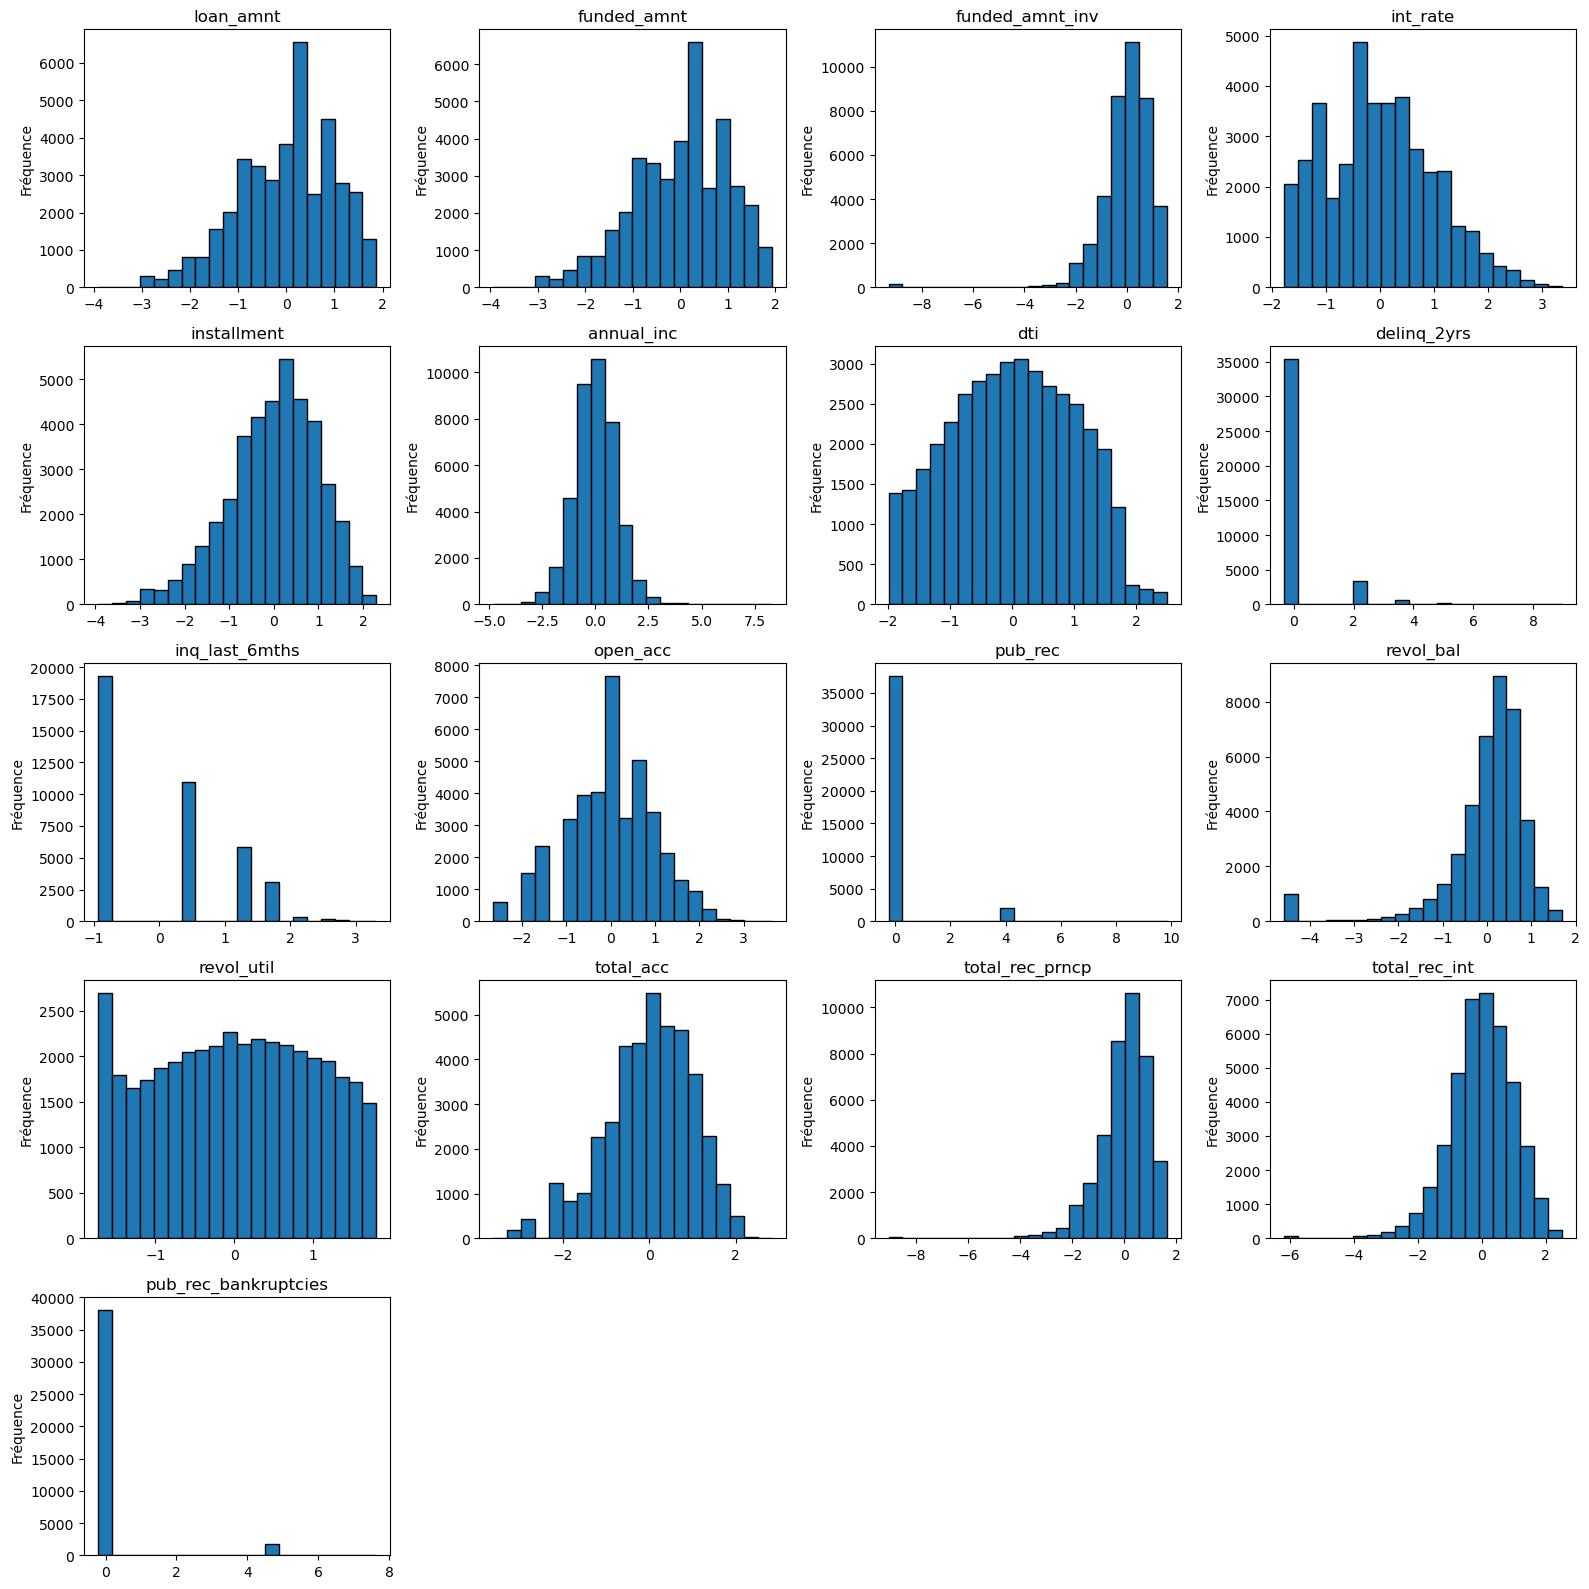

In [98]:
df_data_hist_plot = df_dummies[numeric_cols]
plot_distributions(df_data_hist_plot, bins=20)

## Conclusions

In [99]:
df_final = df_dummies.copy() 
df_final.to_csv('data/transformed.csv') 